# `ggrepel_py` examples (vol. 1)

Python port of additional scenarios from
`https://ggrepel.slowkow.com/articles/examples` that are not covered by
`examples_v2.ipynb`.  Each example names the feature it demonstrates and
mirrors the setup from the R reference.

In [1]:
import numpy as np
import pandas as pd

import grid_py as grid
from grid_py import Unit, arrow

from ggplot2_py import (
    ggplot, aes,
    geom_point, geom_text, geom_col,
    geom_hline, geom_vline,
    theme_classic, theme_bw, theme_void, theme,
    labs, coord_flip, coord_polar, element_blank,
    scale_x_continuous, scale_color_discrete,
    facet_grid, facet_wrap,
    xlim, ylim,
)

from ggrepel_py import geom_text_repel, geom_label_repel
from ggrepel_py.data import load_mtcars

np.random.seed(42)

mtcars = load_mtcars()
if "car" not in mtcars.columns:
    mtcars = mtcars.reset_index().rename(columns={"index": "car"})

dat = mtcars[(mtcars["wt"] > 2.75) & (mtcars["wt"] < 3.45)].copy().reset_index(drop=True)

## 1. `geom_text()` vs `geom_text_repel()`

The classic comparison: overlapping text without repulsion (left) and
the same labels with collision avoidance (right).

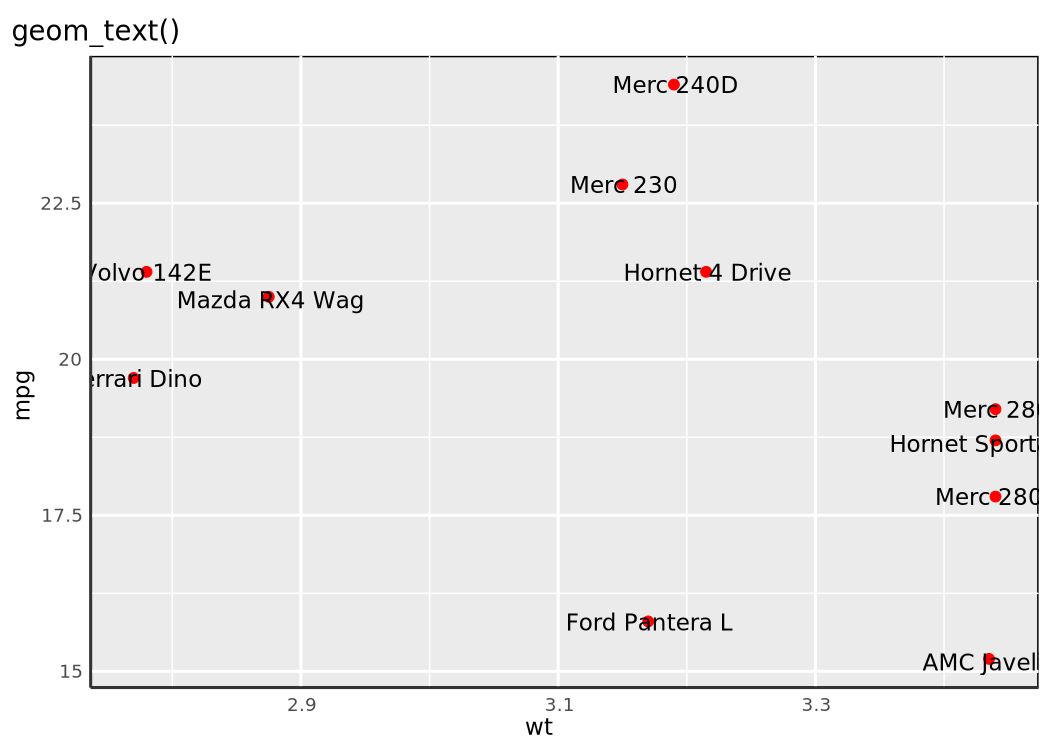

In [2]:
p = ggplot(dat, aes(x='wt', y='mpg', label='car')) + geom_point(color='red')

# geom_text() version
(p + geom_text() + labs(title='geom_text()'))

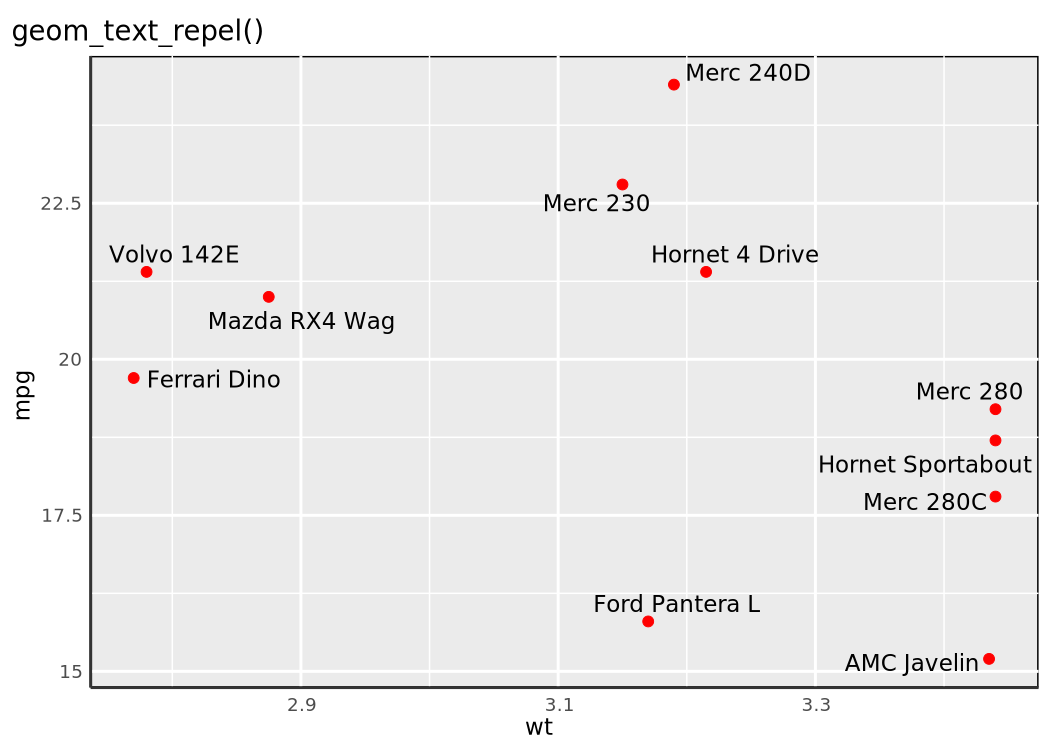

In [3]:
# geom_text_repel() version
(p + geom_text_repel(seed=42) + labs(title='geom_text_repel()'))

## 2. Customise the label border

`geom_label_repel` supports `linewidth` and `linetype` on the label
rectangle itself (equivalent to `geom_rect`).

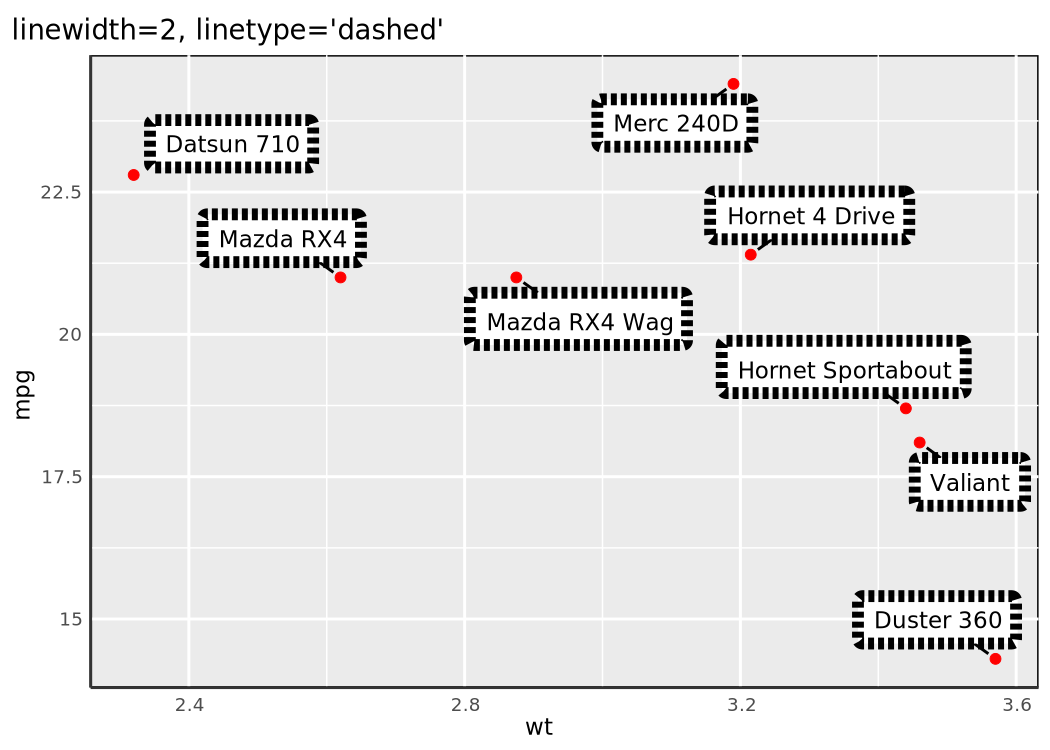

In [4]:
df8 = mtcars.head(8).copy()

(ggplot(df8, aes(x='wt', y='mpg', label='car'))
 + geom_point(color='red')
 + geom_label_repel(fill='white', linewidth=2, linetype='dashed', seed=42, box_padding=0.7)
 + labs(title="linewidth=2, linetype='dashed'"))

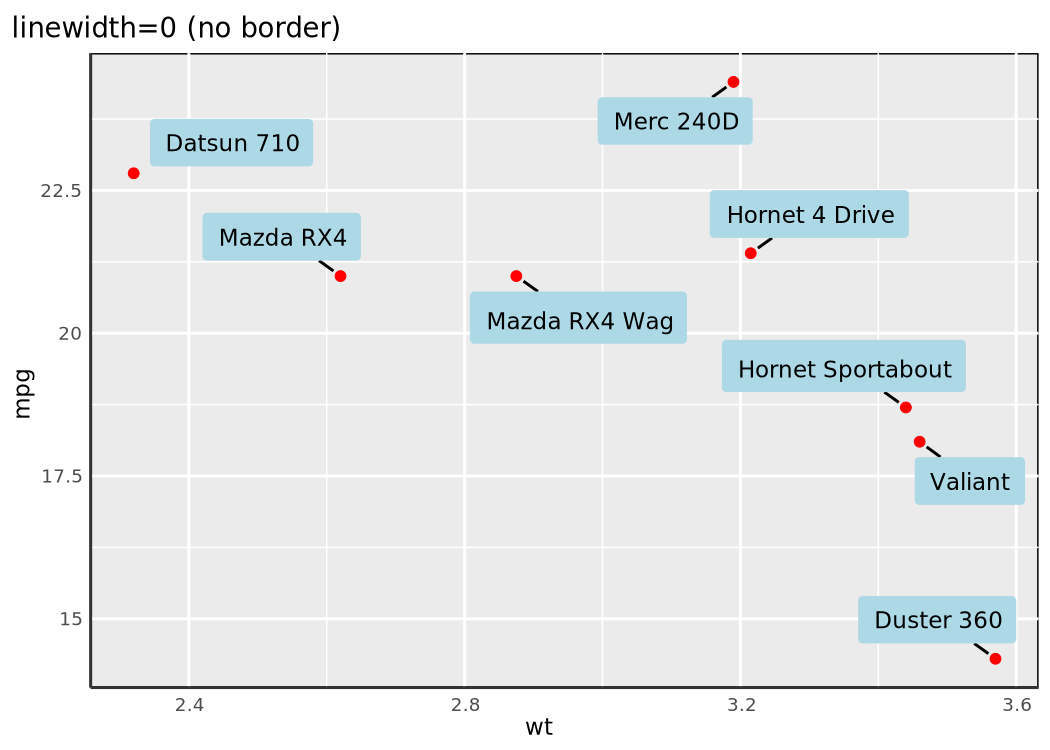

In [5]:
(ggplot(df8, aes(x='wt', y='mpg', label='car'))
 + geom_point(color='red')
 + geom_label_repel(fill='lightblue', linewidth=0, seed=42, box_padding=0.7)
 + labs(title='linewidth=0 (no border)'))

## 3. Adjust line spacing for multi-line labels

`lineheight` controls the distance between lines inside a single label.

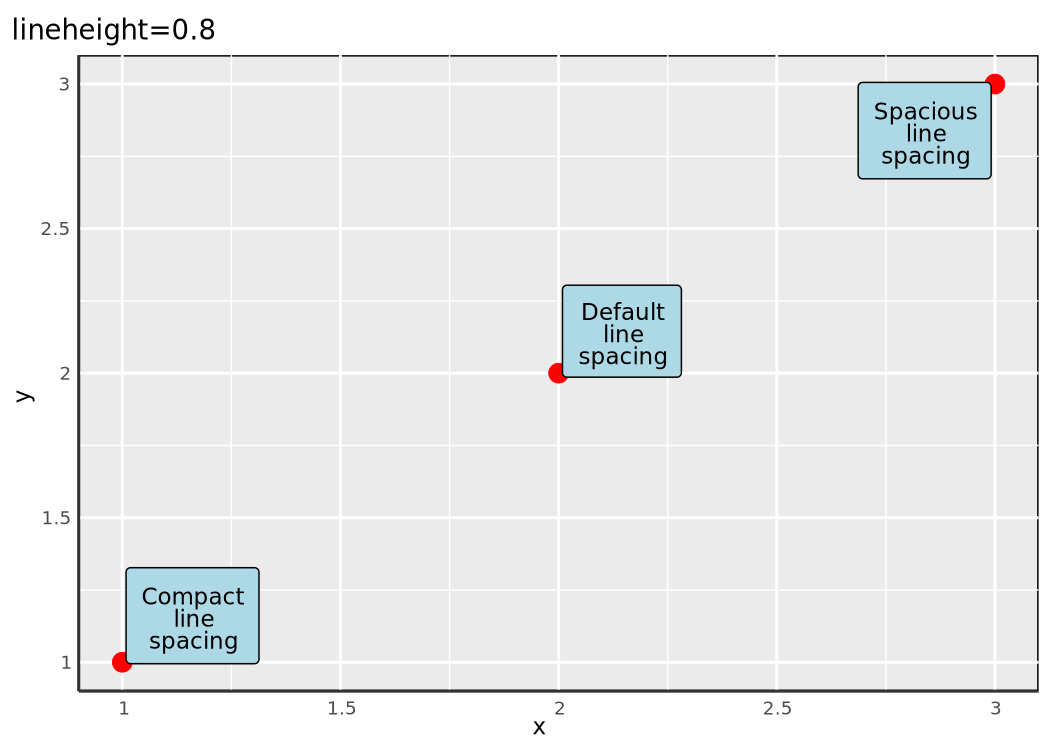

In [6]:
df_ml = pd.DataFrame({
    'x': [1, 2, 3],
    'y': [1, 2, 3],
    'label': [
        'Compact\nline\nspacing',
        'Default\nline\nspacing',
        'Spacious\nline\nspacing',
    ],
})

(ggplot(df_ml, aes(x='x', y='y', label='label'))
 + geom_point(color='red', size=3)
 + geom_label_repel(lineheight=0.8, fill='lightblue', seed=42, box_padding=0.3)
 + labs(title='lineheight=0.8'))

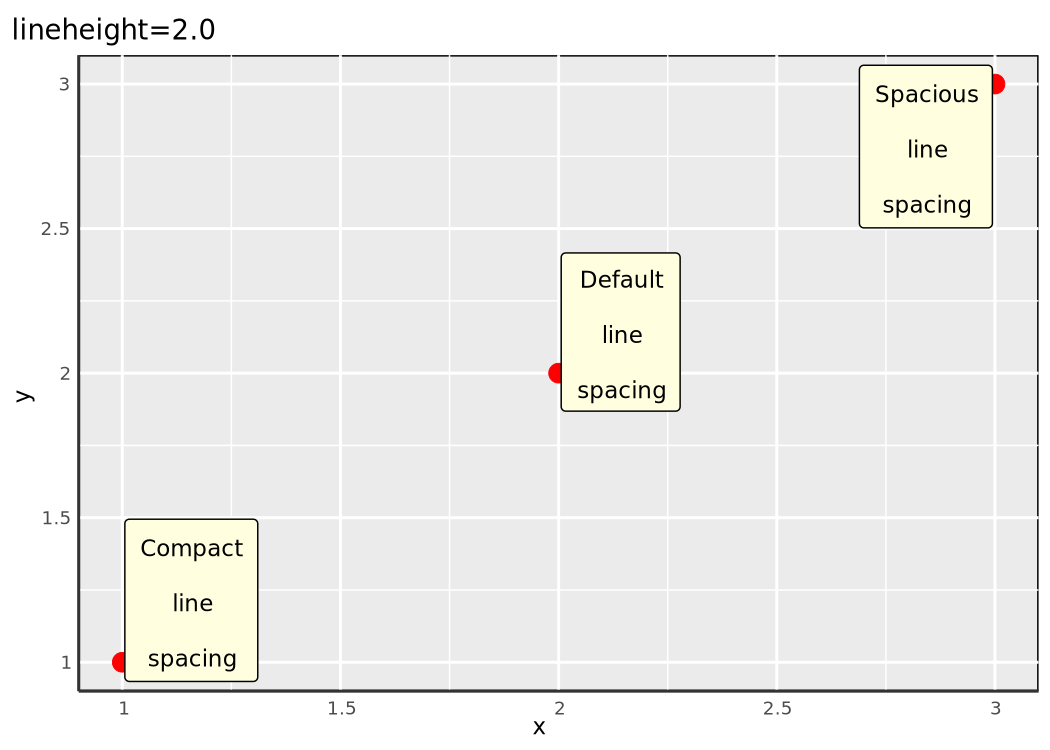

In [7]:
(ggplot(df_ml, aes(x='x', y='y', label='label'))
 + geom_point(color='red', size=3)
 + geom_label_repel(lineheight=2.0, fill='lightyellow', seed=42)
 + labs(title='lineheight=2.0'))

## 4. Limit labels to a specific x-area, with arrows

Constrain labels to the right half of the panel (`xlim=(3, inf)`) and
join them to their points with closed-tip arrows.

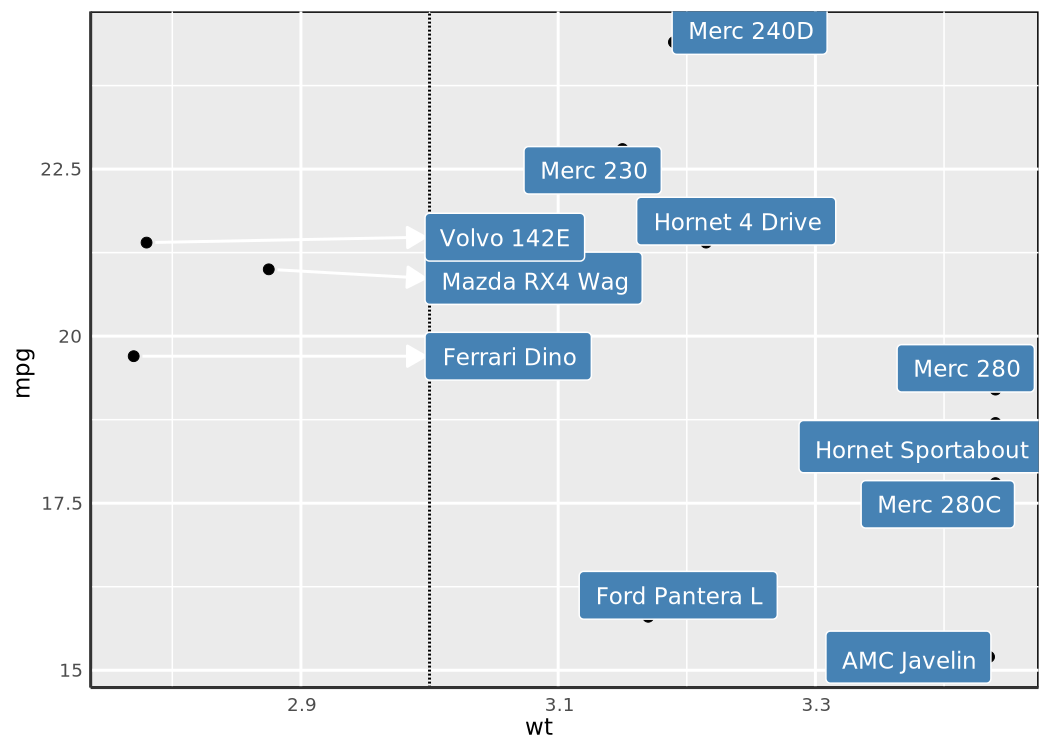

In [8]:
(ggplot(dat, aes(x='wt', y='mpg', label='car'))
 + geom_vline(xintercept=3, linetype='dotted')
 + geom_point()
 + geom_label_repel(
     color='white', fill='steelblue',
     arrow=arrow(length=Unit(0.03, 'npc'), type='closed', ends='first'),
     xlim=(3, float('inf')),
     box_padding=0.1, seed=42,
 ))

## 5. Align labels on the top/bottom edge of the plot

`direction='x'` restricts repulsion to the horizontal axis; combined
with `angle=90` the labels are rotated vertically and pushed along the
top.

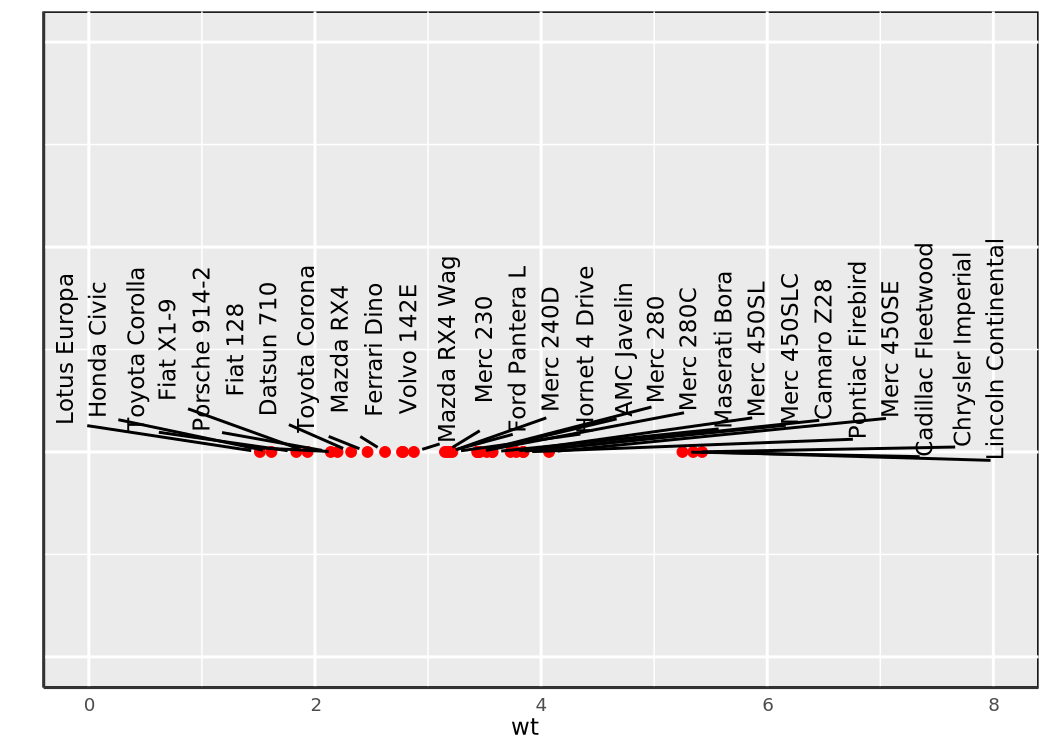

In [9]:
dat_top = mtcars.copy()
dat_top['y'] = 1.0

(ggplot(dat_top, aes(x='wt', y='y', label='car'))
 + geom_point(color='red')
 + geom_text_repel(
     force_pull=0, nudge_y=0.05, direction='x',
     angle=90, hjust=0, seed=42,
     max_iter=10000, max_time=1.0,
 )
 + xlim(0, 8) + ylim(0.9, 1.2)
 + theme(
     axis_line_y=element_blank(),
     axis_ticks_y=element_blank(),
     axis_text_y=element_blank(),
     axis_title_y=element_blank(),
 ))

## 6. Align labels on the left/right edge of the plot

`direction='y'` allows only vertical movement; the three panels below
show `hjust=0 / 0.5 / 1`.

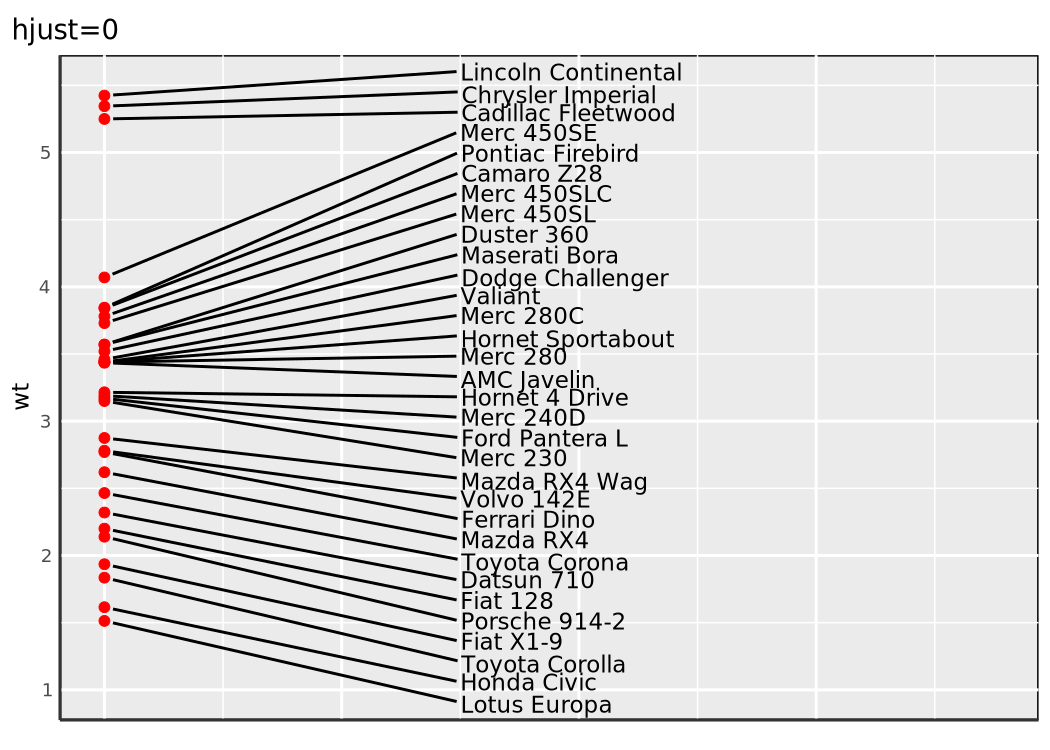

In [10]:
# hjust=0 — labels anchored to left side of their nudged position
(ggplot(mtcars, aes(y='wt', x=1, label='car'))
 + geom_point(color='red')
 + ylim(1, 5.5) + xlim(1, 1.375)
 + geom_text_repel(force=0.5, nudge_x=0.15, direction='y', hjust=0, seed=42)
 + theme(
     axis_line_x=element_blank(),
     axis_ticks_x=element_blank(),
     axis_text_x=element_blank(),
     axis_title_x=element_blank(),
 )
 + labs(title='hjust=0'))

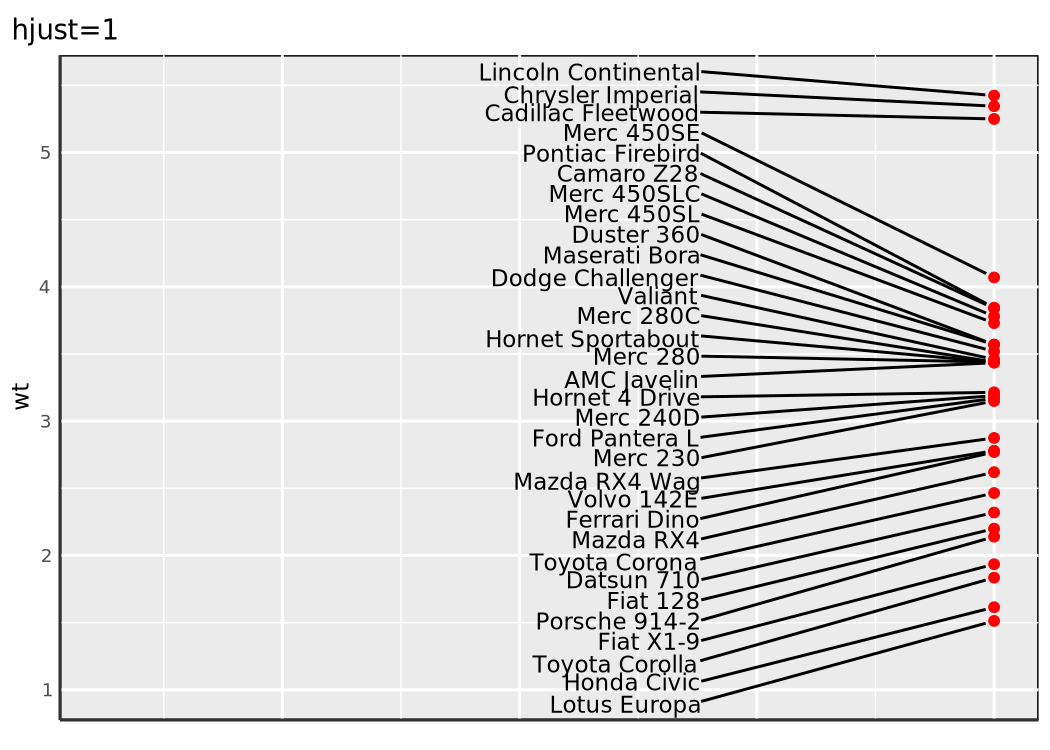

In [11]:
# hjust=1 — labels anchored to right side
(ggplot(mtcars, aes(y='wt', x=1, label='car'))
 + geom_point(color='red')
 + ylim(1, 5.5) + xlim(0.25, 1)
 + geom_text_repel(force=0.5, nudge_x=-0.25, direction='y', hjust=1, seed=42)
 + theme(
     axis_line_x=element_blank(),
     axis_ticks_x=element_blank(),
     axis_text_x=element_blank(),
     axis_title_x=element_blank(),
 )
 + labs(title='hjust=1'))

## 7. Multi-line label justification

Per-row `hjust` lets one label hug the right edge while another sits
on the left; the arrow spec is applied uniformly.

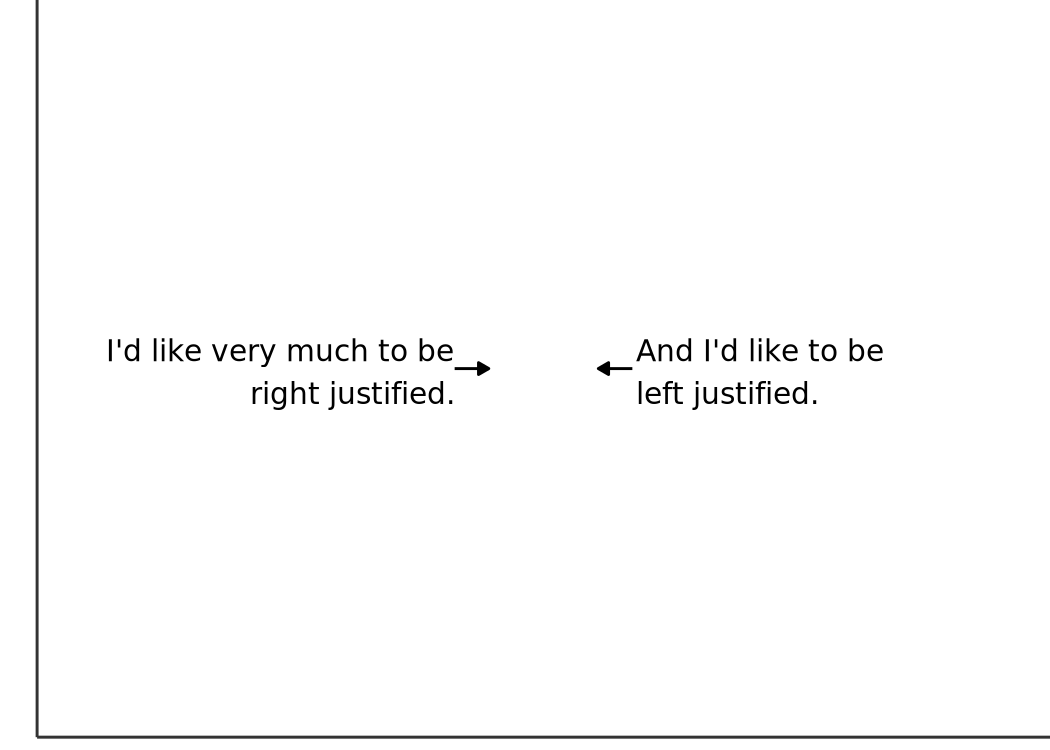

In [12]:
label_df = pd.DataFrame({
    'x': [0.45, 0.55],
    'y': [0.5, 0.5],
    'g': [
        "I'd like very much to be\nright justified.",
        "And I'd like to be\nleft justified.",
    ],
})

(ggplot()
 + geom_text_repel(
     data=label_df,
     mapping=aes(x='x', y='y', label='g'),
     size=5,
     hjust=[1, 0],
     nudge_x=[-0.05, 0.05],
     arrow=arrow(length=Unit(2, 'mm'), ends='last', type='closed'),
     seed=42,
 )
 + xlim(0, 1) + ylim(0, 1)
 + theme_void())

## 8. Shadow under text labels

`bg_colour` / `bg_r` add a halo of offset text grobs underneath the
main text for improved legibility over busy backgrounds.

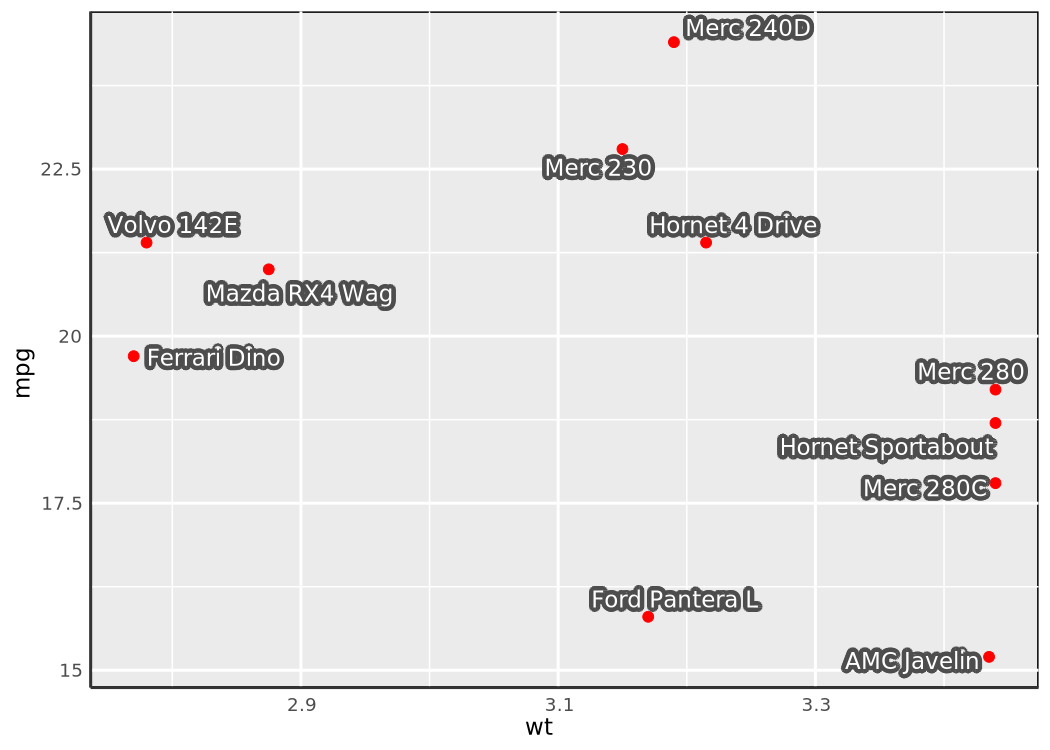

In [13]:
(ggplot(dat, aes(x='wt', y='mpg', label='car'))
 + geom_point(color='red')
 + geom_text_repel(color='white', bg_colour='grey30', bg_r=0.15, seed=42))

## 9. Word cloud

`force_pull=0` removes the spring that keeps labels close to their
data points; combined with `max_overlaps=inf` and `segment_colour=None`
the labels pack into a tight cloud around the origin.

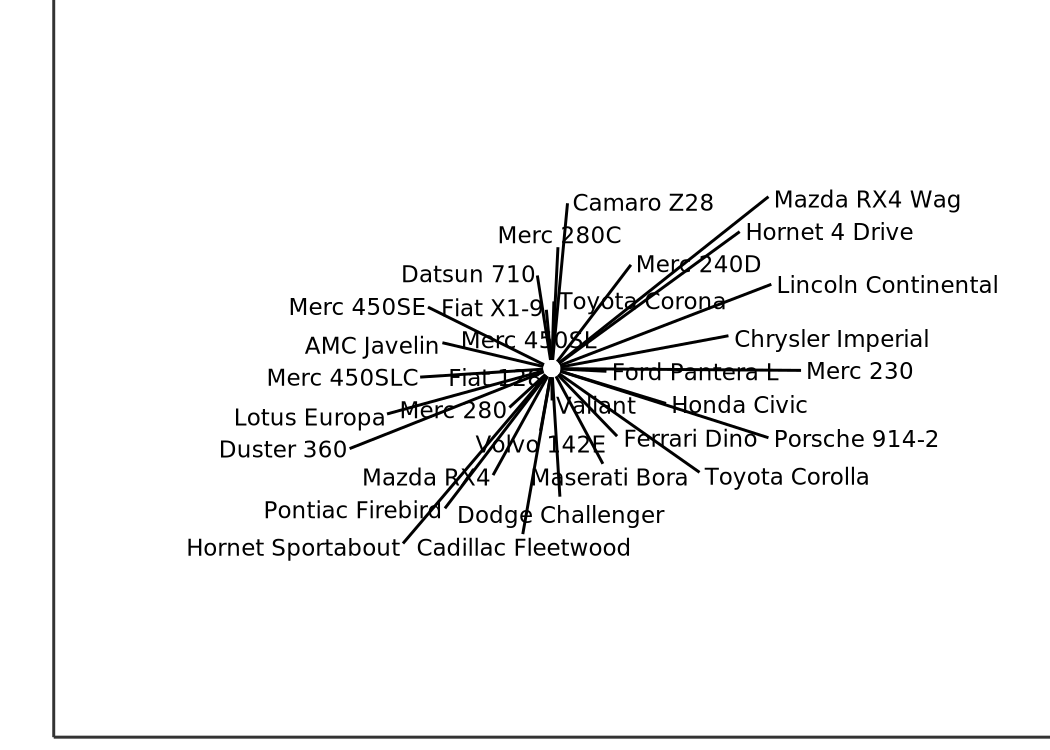

In [14]:
cloud = mtcars.copy()
cloud['x'] = 0.0
cloud['y'] = 0.0

(ggplot(cloud, aes(x='x', y='y', label='car'))
 + geom_text_repel(
     force_pull=0,
     max_time=0.5, max_iter=100000,
     max_overlaps=float('inf'),
     point_padding=None,
     segment_colour=None,
     seed=42,
 )
 + theme_void())

## 10. `coord_flip()`

Swapping the axes after the fact — labels still avoid overlaps in the
flipped coordinate system.

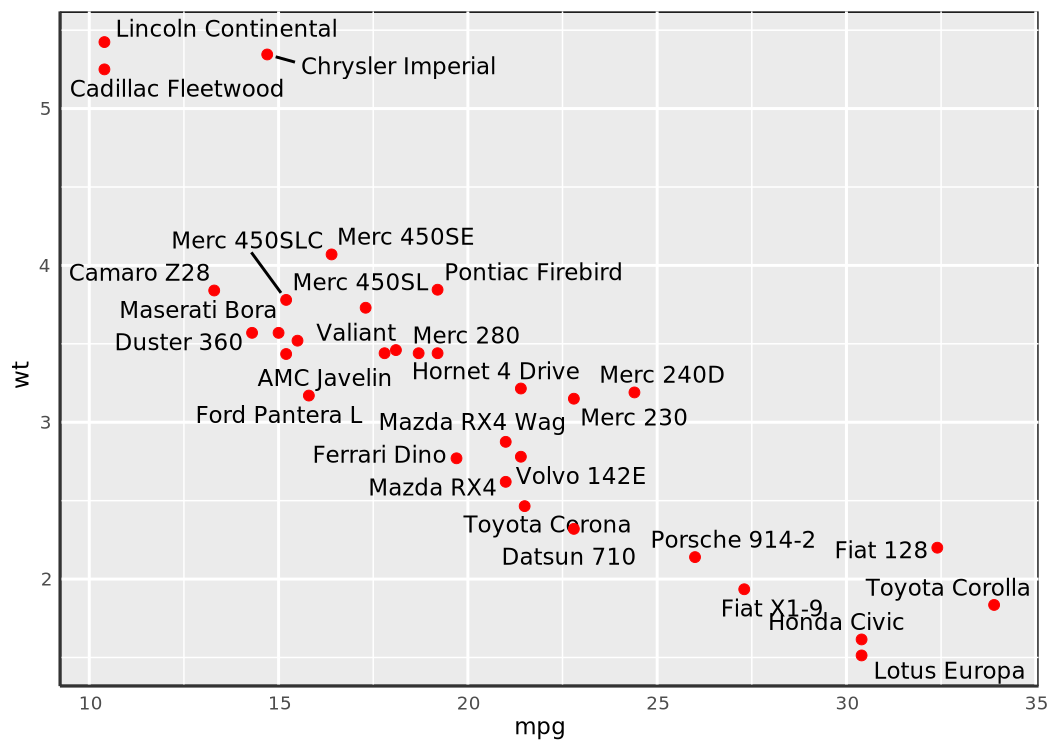

In [15]:
p_flip = (ggplot(mtcars, aes(x='wt', y='mpg', label='car'))
          + geom_text_repel(seed=42)
          + geom_point(color='red'))

p_flip + coord_flip()

## 11. Polar coordinates (`coord_polar`)

`coord_polar(theta='x')` maps the x aesthetic to an angle.  `geom_text_repel`
resolves label positions in the transformed (polar) panel, so labels follow
the ring and do not overlap.  Labels for rows with `mpg < 25` are blanked
out so the plot only highlights the top-mileage cars.

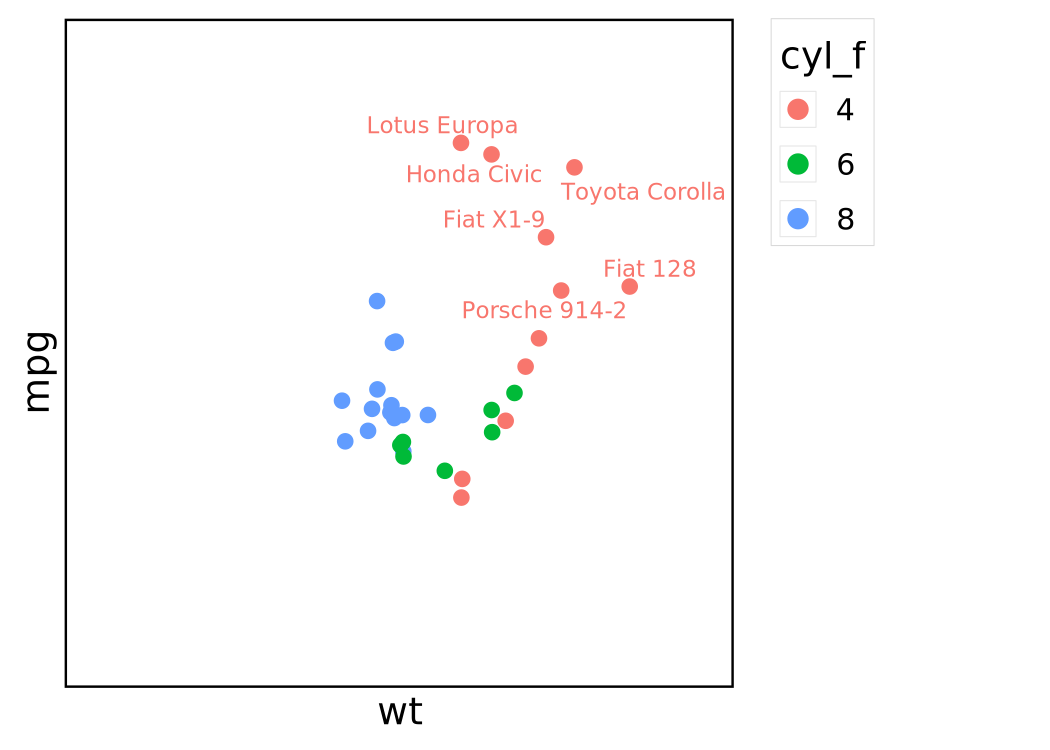

In [16]:
mtcars_polar = mtcars.copy()
mtcars_polar['label'] = mtcars_polar['car']
mtcars_polar.loc[mtcars_polar['mpg'] < 25, 'label'] = ''
mtcars_polar['cyl_f'] = mtcars_polar['cyl'].astype(str)

(ggplot(mtcars_polar, aes(x='wt', y='mpg', color='cyl_f', label='label'))
 + coord_polar(theta='x')
 + geom_point(size=2)
 + scale_color_discrete(name='cyl')
 + geom_text_repel(seed=42, show_legend=False)
 + theme_bw(base_size=18))

## 12. `segment_square` / `segment_inflect` (facet_grid)

`facet_grid(square ~ inflect)` shows the four combinations of
`segment_square` × `segment_inflect`.  Both aesthetics are mapped per-row
via `aes(segment_square=..., segment_inflect=...)` so each facet sees a
different curve topology.

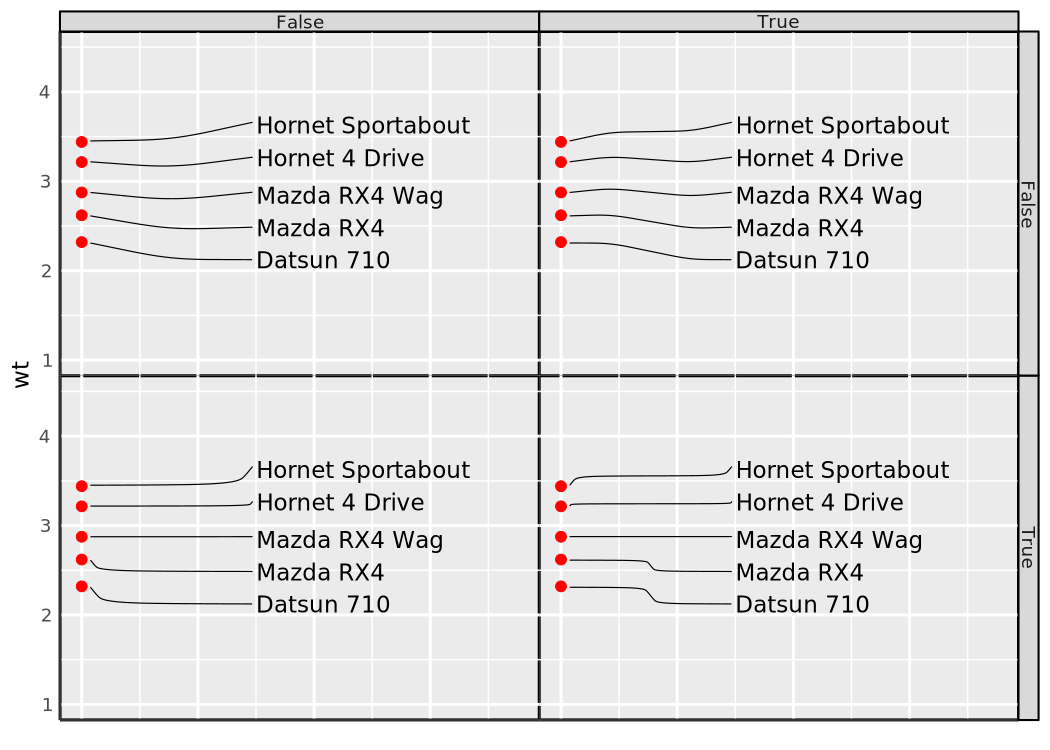

In [17]:
cars_subset = mtcars.head(5).copy().reset_index(drop=True)

cars_subset_curves = pd.concat([cars_subset] * 4, ignore_index=True)
cars_subset_curves['square'] = np.repeat([True, False], len(cars_subset) * 2)
cars_subset_curves['inflect'] = np.repeat([True, False, True, False], len(cars_subset))

(ggplot(cars_subset_curves, aes(y='wt', x=1, label='car'))
 + facet_grid(rows='square', cols='inflect')
 + geom_point(color='red')
 + ylim(1, 4.5) + xlim(1, 1.375)
 + geom_text_repel(
     aes(segment_square='square', segment_inflect='inflect'),
     force=0.5, nudge_x=0.15, direction='y', hjust=0,
     segment_size=0.2, segment_curvature=-0.1,
     seed=42,
 )
 + theme(
     axis_line_x=element_blank(),
     axis_ticks_x=element_blank(),
     axis_text_x=element_blank(),
     axis_title_x=element_blank(),
 ))

## 13. `segment_shape` (facet_wrap)

`segment_shape` controls the curve shape parameter.  Values from -1 to 1
produce progressively different curve profiles; `facet_wrap('shape')`
lays them out vertically.

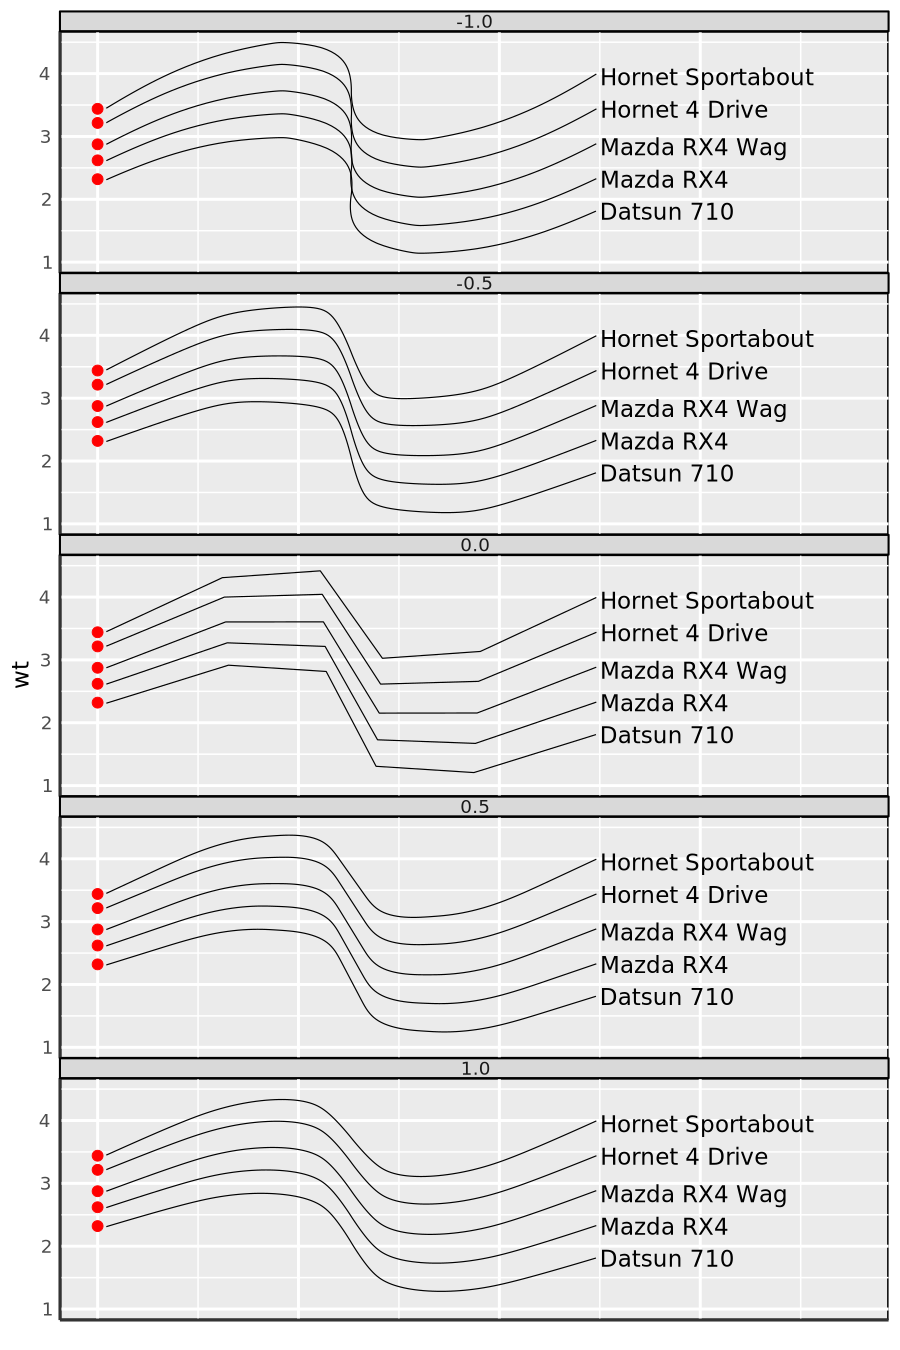

In [18]:
cars_subset_shapes = pd.concat([cars_subset] * 5, ignore_index=True)
cars_subset_shapes['shape'] = np.repeat([-1, -0.5, 0, 0.5, 1], len(cars_subset))

# Taller figure so each of the 5 stacked panels has room for the curve peaks
# (default 7x5in ≈ 1in per panel, too short for curvature=-0.6 + angle=45).
p = (ggplot(cars_subset_shapes, aes(y='wt', x=1, label='car'))
 + facet_wrap('shape', ncol=1)
 + geom_point(color='red')
 + ylim(1, 4.5) + xlim(1, 1.375)
 + geom_text_repel(
     aes(segment_shape='shape'),
     force=0.5, nudge_x=0.25, direction='y', hjust=0,
     segment_size=0.2, segment_curvature=-0.6,
     segment_angle=45, segment_ncp=2,
     segment_square=False, segment_inflect=True,
     seed=42,
 )
 + theme(
     axis_line_x=element_blank(),
     axis_ticks_x=element_blank(),
     axis_text_x=element_blank(),
     axis_title_x=element_blank(),
 ))
p.fig_width = 6
p.fig_height = 9
p